In [136]:
import numpy as np
import matplotlib.pyplot as plt
import meanderpy as mp

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 1000

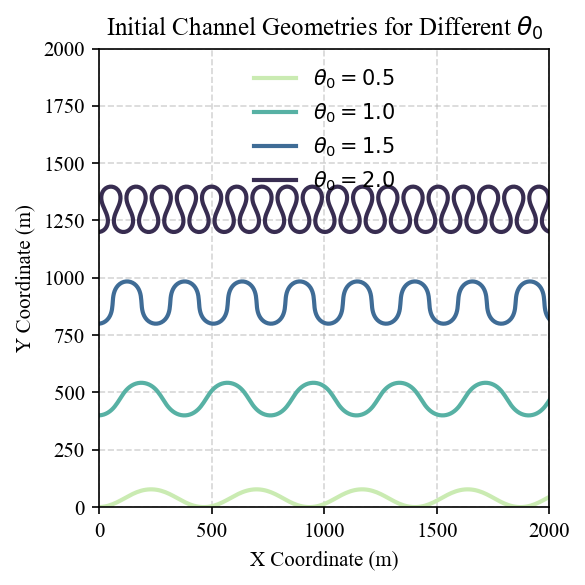

In [148]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean

lamb = 500.0
total_length = 10000.0
n_nodes = 1000
base_angle = 0.0

s = np.linspace(0.0, total_length, n_nodes)

theta_values = [0.5, 1.0, 1.5, 2.0]

cmap = cmocean.cm.deep
colors = cmap(np.linspace(0.1, 0.9, len(theta_values)))

y_offsets = np.arange(len(theta_values)) * 400.0

plt.figure(figsize=(4, 4), dpi=150)

for theta0, color, y0 in zip(theta_values, colors, y_offsets):
    theta = theta0 * np.sin(2.0 * np.pi * s / lamb) + base_angle

    x = np.zeros_like(s)
    y = np.zeros_like(s)

    x[0] = 0.0
    y[0] = y0

    for i in range(1, n_nodes):
        ds = s[i] - s[i-1]
        x[i] = x[i-1] + ds * np.cos(theta[i])
        y[i] = y[i-1] + ds * np.sin(theta[i])

    plt.plot(x, y, linewidth=2, color=color, label=rf"$\theta_0 = {theta0}$")

plt.title("Initial Channel Geometries for Different $\\theta_0$")
plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")
plt.xlim([0, 2000])
plt.ylim([0, 2000])
plt.legend(frameon=False)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Benettin's algorithm

In [ ]:
SECONDS_PER_YEAR = 365.25 * 24 * 3600
NIT_PER_CHUNK = 1001
N_CHUNKS = 10
W = 100.0
MAG = 1e-5
EXTENT = (0, 1000, -2500, 2500)
KL_M_PER_YR = 100.0
CRDIST = 1 * W
KV_M_PER_YR = 3.16e-5
DT_YEARS = 0.1
cell_size = 10.0

kl = KL_M_PER_YR / SECONDS_PER_YEAR
kv = KV_M_PER_YR / SECONDS_PER_YEAR
dt = DT_YEARS * SECONDS_PER_YEAR

def create_base_channel(pert, crdist):
    theta0 = 2
    n_nodes = 1000
    total_length = 10000.0
    lamb = 500.0
    base_angle = 0.0

    s = np.linspace(0.0, total_length, n_nodes)
    theta = theta0 * np.sin(2.0 * np.pi * s / lamb) + base_angle

    x = np.zeros_like(s)
    y = np.zeros_like(s)
    for i in range(1, n_nodes):
        ds = s[i] - s[i-1]
        x[i] = x[i-1] + ds * np.cos(theta[i])
        y[i] = y[i-1] + ds * np.sin(theta[i])

    if pert != 0.0:
        mid = len(x) // 2
        y[mid] += pert

    z = np.zeros_like(x)
    return mp.Channel(x, y, z, W, 1.0)

def get_log_diff(ch1, ch2, cell_size):
    if ch1 is None or ch2 is None:
        return np.nan

    x_all = np.concatenate([ch1.x, ch2.x])
    y_all = np.concatenate([ch1.y, ch2.y])

    xmin = x_all.min()
    xmax = x_all.max()
    ymin = y_all.min()
    ymax = y_all.max()

    xmin_snap = np.floor(xmin / cell_size) * cell_size
    xmax_snap = np.ceil(xmax / cell_size) * cell_size
    ymin_snap = np.floor(ymin / cell_size) * cell_size
    ymax_snap = np.ceil(ymax / cell_size) * cell_size

    cols = int((xmax_snap - xmin_snap) / cell_size)
    rows = int((ymax_snap - ymin_snap) / cell_size)

    def raster(c):
        g = np.zeros((rows, cols), dtype=bool)
        xs = np.linspace(c.x[:-1], c.x[1:], 10)
        ys = np.linspace(c.y[:-1], c.y[1:], 10)
        col_idx = ((xs - xmin_snap) / cell_size).astype(int)
        row_idx = ((ys - ymin_snap) / cell_size).astype(int)
        mask = (0 <= col_idx) & (col_idx < cols) & (0 <= row_idx) & (row_idx < rows)
        g[row_idx[mask], col_idx[mask]] = True
        return g.astype(int)

    g1 = raster(ch1)
    g2 = raster(ch2)

    return_val = np.count_nonzero(g1 != g2)
    return np.log(return_val) if return_val > 0 else np.nan

ch_ref_start = create_base_channel(pert=0.0, crdist=CRDIST)
ch_pert_start = create_base_channel(pert=MAG, crdist=CRDIST)

chb_ref = mp.ChannelBelt([ch_ref_start], [], [0.0], [])
chb_pert = mp.ChannelBelt([ch_pert_start], [], [0.0], [])

all_log_norms = []
global_time_indices = []
current_global_idx = 0

for chunk_idx in range(N_CHUNKS):
    print(f"Running Chunk {chunk_idx + 1}/{N_CHUNKS}...")

    if chunk_idx > 0:
        ref_last_channel = chb_ref.channels[-1]

        new_x = ref_last_channel.x.copy()
        new_y = ref_last_channel.y.copy()
        new_z = ref_last_channel.z.copy()

        mid = len(new_y) // 2
        new_y[mid] += MAG

        channel_reset = mp.Channel(new_x, new_y, new_z, W, 1.0)
        chb_pert.channels[-1] = channel_reset

    saved_ts = 1
    deltas = 50.0
    pad = 0
    dens = 1000
    t1 = t2 = t3 = 0
    aggr_factor = 0.0

    depths = np.ones(NIT_PER_CHUNK)
    Cfs = 0.0065 * np.ones(NIT_PER_CHUNK)

    chb_ref.migrate(
        NIT_PER_CHUNK, saved_ts, deltas, pad, CRDIST,
        depths, Cfs, kl, kv, dt, dens, t1, t2, t3, aggr_factor
    )

    chb_pert.migrate(
        NIT_PER_CHUNK, saved_ts, deltas, pad, CRDIST,
        depths, Cfs, kl, kv, dt, dens, t1, t2, t3, aggr_factor
    )

    total_len = len(chb_ref.channels)
    start_idx = total_len - NIT_PER_CHUNK

    step = 1
    chunk_indices = range(start_idx, total_len, step)

    for i in chunk_indices:
        val = get_log_diff(chb_ref.channels[i], chb_pert.channels[i], cell_size)
        all_log_norms.append(val)
        global_time_indices.append(current_global_idx + (i - start_idx))

    current_global_idx += NIT_PER_CHUNK

print("Simulation complete. Plotting...")

y_data = np.array(all_log_norms)
t_data = np.array(global_time_indices) * DT_YEARS

mask = np.isfinite(y_data)
t_final = t_data[mask]
y_final = y_data[mask]

Running Chunk 1/10...


  0%|          | 0/1001 [00:00<?, ?it/s]

100%|██████████| 1001/1001 [00:00<00:00, 1265.65it/s]


Running Chunk 2/10...


100%|██████████| 1001/1001 [00:01<00:00, 821.61it/s]


...

Running Chunk 9/10...


100%|██████████| 1001/1001 [00:15<00:00, 64.32it/s]


Running Chunk 10/10...


100%|██████████| 1001/1001 [00:16<00:00, 62.47it/s]


Simulation complete. Plotting...


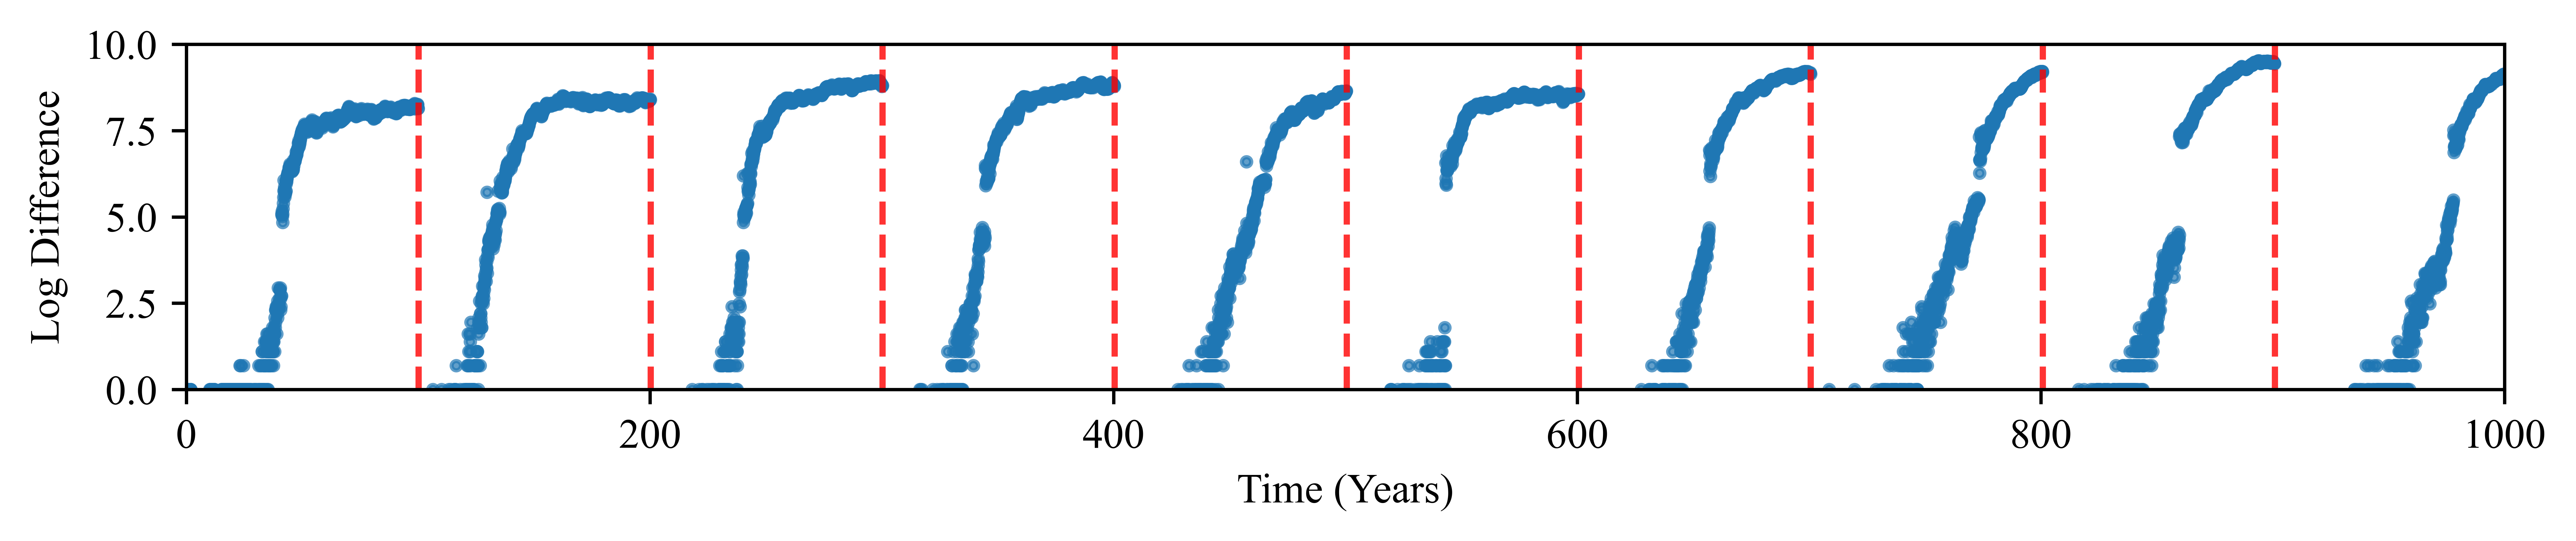

In [137]:
plt.figure(figsize=(10, 1.5))
plt.scatter(t_final, y_final, s=5, alpha=0.7, label='Log Diff')

time_per_chunk = NIT_PER_CHUNK * DT_YEARS

for i in range(1, N_CHUNKS):
    plt.axvline(x=i * time_per_chunk, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

plt.xlabel("Time (Years)")
plt.ylabel("Log Difference")
plt.xlim([0, 1000])
plt.ylim([0, 10])
plt.plot([], [], color='red', linestyle='--', linewidth=1, label='Reset')

plt.show()

[0.17276798858866846, 0.2702287411337351, 0.35563106093262653, 0.31013754182743014, 0.20991675576313665, 0.34244276660024503, 0.28894749063942154, 0.17273537935078762, 0.21867274543385043, 0.20392260182270314]


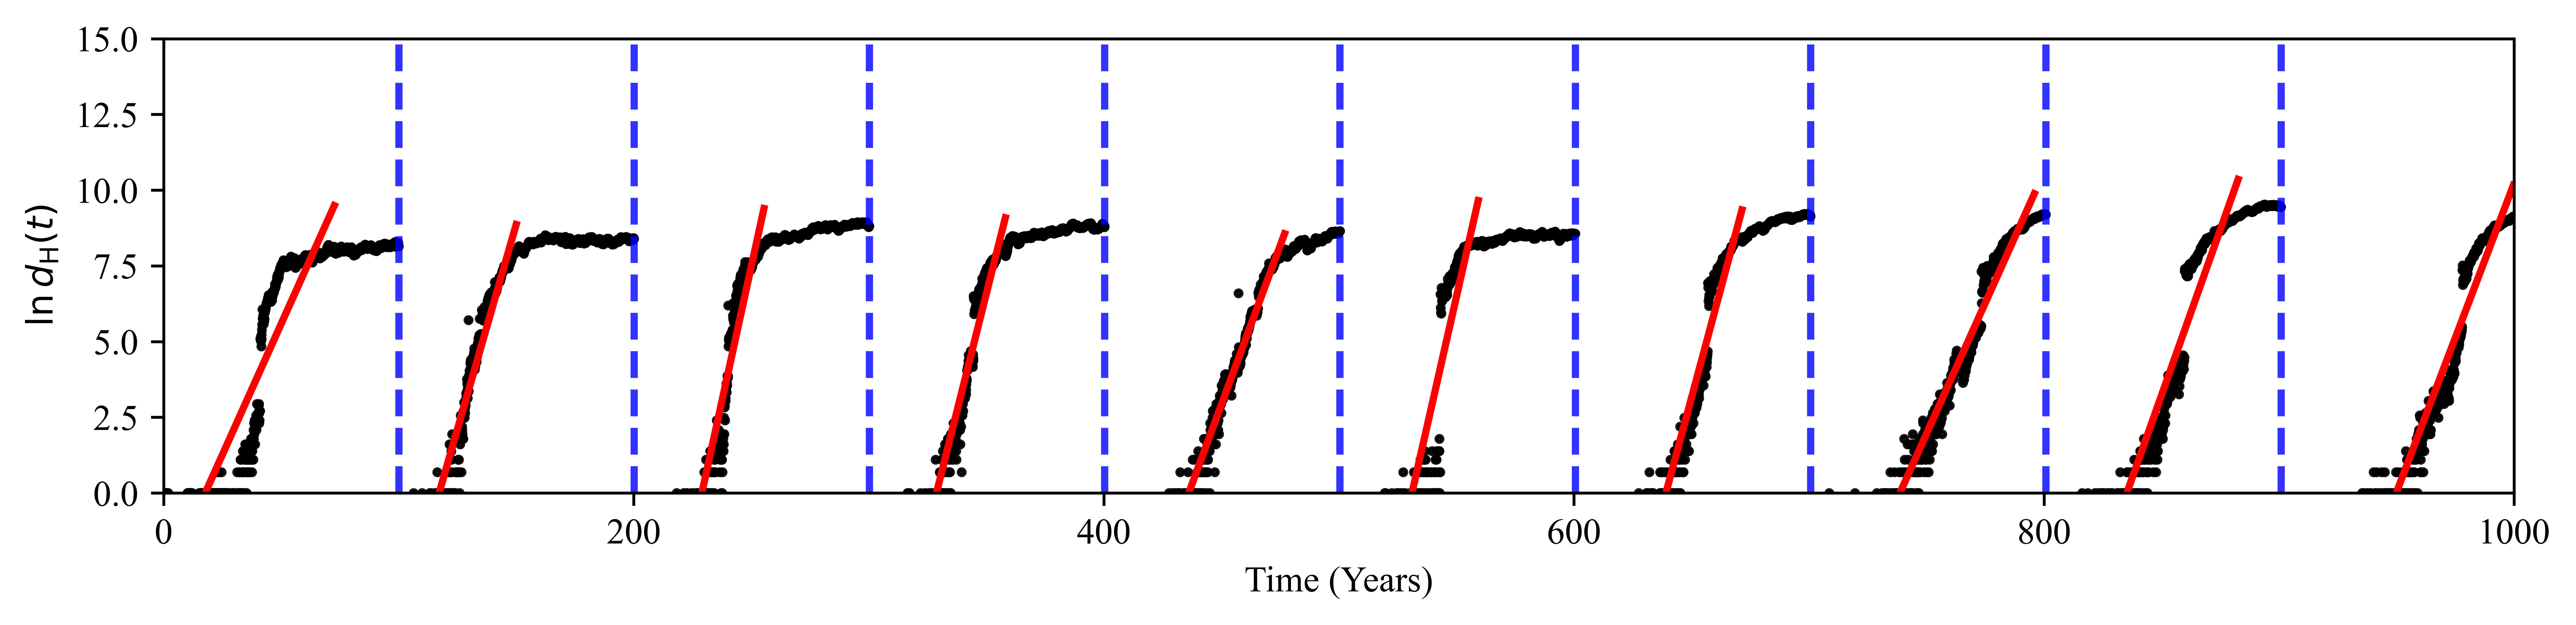

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

slopes = []
fits_data = []

time_per_chunk = NIT_PER_CHUNK * DT_YEARS

for i in range(N_CHUNKS):
    t_start = i * time_per_chunk
    t_end = (i + 1) * time_per_chunk

    chunk_mask = (t_final >= t_start) & (t_final < t_end)
    t_chunk = t_final[chunk_mask]
    y_chunk = y_final[chunk_mask]

    if len(t_chunk) < 5:
        continue

    best_r2 = -np.inf
    best_slope = 0.0
    best_intercept = 0.0
    best_end_idx = 0

    min_window = 10

    for end_idx in range(min_window, len(t_chunk)):
        t_sub = t_chunk[:end_idx]
        y_sub = y_chunk[:end_idx]

        slope, intercept, r_value, p_value, std_err = linregress(t_sub, y_sub)

        current_r2 = r_value**2
        if current_r2 > best_r2:
            best_r2 = current_r2
            best_slope = slope
            best_intercept = intercept
            best_end_idx = end_idx

    slopes.append(best_slope)

    t_fit_plot = t_chunk[:best_end_idx]
    y_fit_plot = best_slope * t_fit_plot + best_intercept

    fits_data.append((t_fit_plot, y_fit_plot))

avg_slope = np.mean(slopes)
slope_std = np.std(slopes)

print(slopes)

plt.figure(figsize=(10, 2.5))

plt.scatter(t_final, y_final, s=3, alpha=0.9, color='black', label='Log Diff Data')

for i in range(1, N_CHUNKS):
    plt.axvline(x=i * time_per_chunk, color='blue', linestyle='--', linewidth=2, alpha=0.8)

label_added = False
for t_fit, y_fit in fits_data:
    if not label_added:
        plt.plot(t_fit, y_fit, color='red', linewidth=2, label='Individual Best Fit')
        label_added = True
    else:
        plt.plot(t_fit, y_fit, color='red', linewidth=2)

x_avg = np.linspace(0, 200, 100)
y_avg = avg_slope * x_avg

plt.xlabel("Time (Years)")
plt.ylabel(r"$\ln d_{\mathrm{H}}(t)$")
plt.xlim([0, 1000])
plt.ylim([0, 15])

plt.tight_layout()
plt.show()

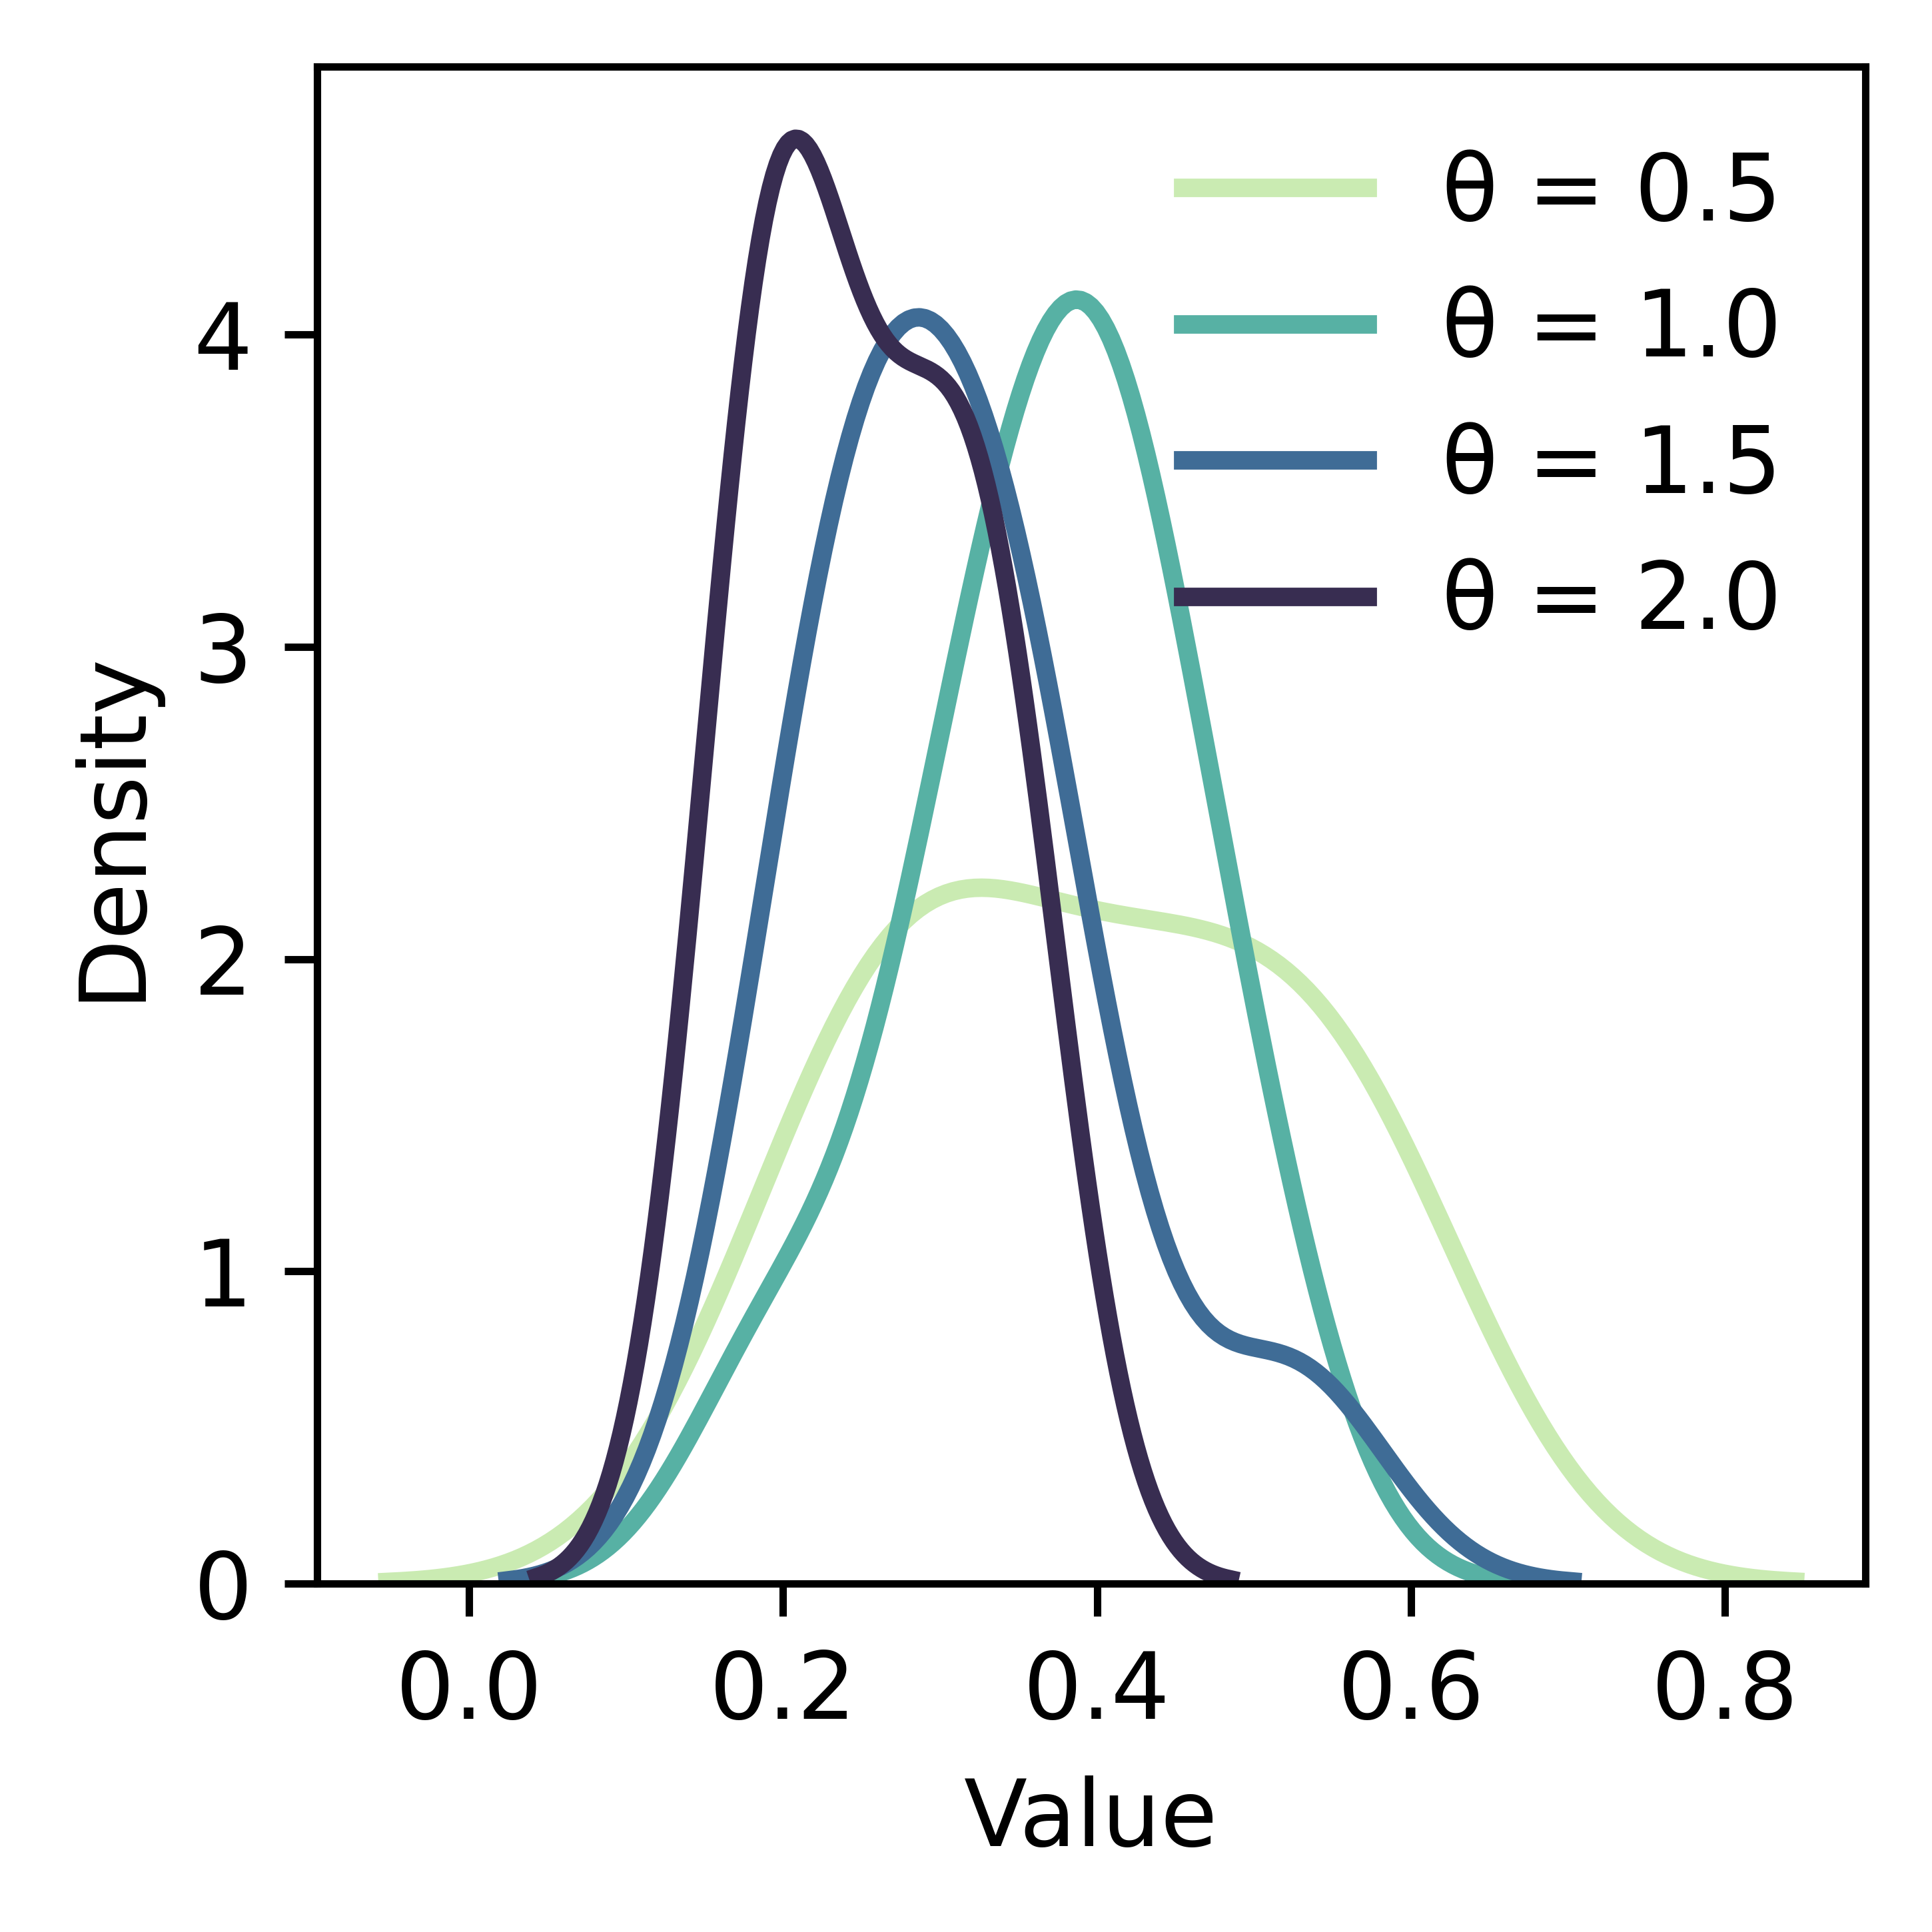

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cmocean

# Data
vals = {
    0.5: [0.2012547514396213, 0.4355469666365899, 0.4418331220590611, 0.554701109073589, 0.5252341046980533, 0.30007916347890135, 0.27194763880467815, 0.2763237778734117, 0.37316187385463667, 0.5914631092263344],
    1.0: [0.1944202696448967, 0.4643840276143645, 0.33186049977665394, 0.3218499732172743, 0.3977197570160754, 0.40885813589367825, 0.4984096263673129, 0.28935321536724457, 0.38874984568543636, 0.3982750825585749],
    1.5: [0.20262738953730222, 0.24601775690267652, 0.2756296548726687, 0.26873160614462055, 0.5247292126128398, 0.3254209452606462, 0.32756323618559, 0.3763095062331945, 0.36136738690545356, 0.22342997456897418],
    2.0: [0.17276798858866846, 0.2702287411337351, 0.35563106093262653, 0.31013754182743014, 0.20991675576313665, 0.34244276660024503, 0.28894749063942154, 0.17273537935078762, 0.21867274543385043, 0.20392260182270314]
}

# Colormap sampling
cmap = cmocean.cm.deep
colors = cmap(np.linspace(0.1, 0.9, len(vals)))  # 4 spaced colors

plt.figure(figsize=(3,3))

for (theta, data), color in zip(vals.items(), colors):
    sns.kdeplot(
        data,
        color=color,
        linewidth=2,
        label=f"θ = {theta}",
        fill=False  # set True if you want shaded KDEs
    )

plt.xlabel("Value")
plt.ylabel("Density")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

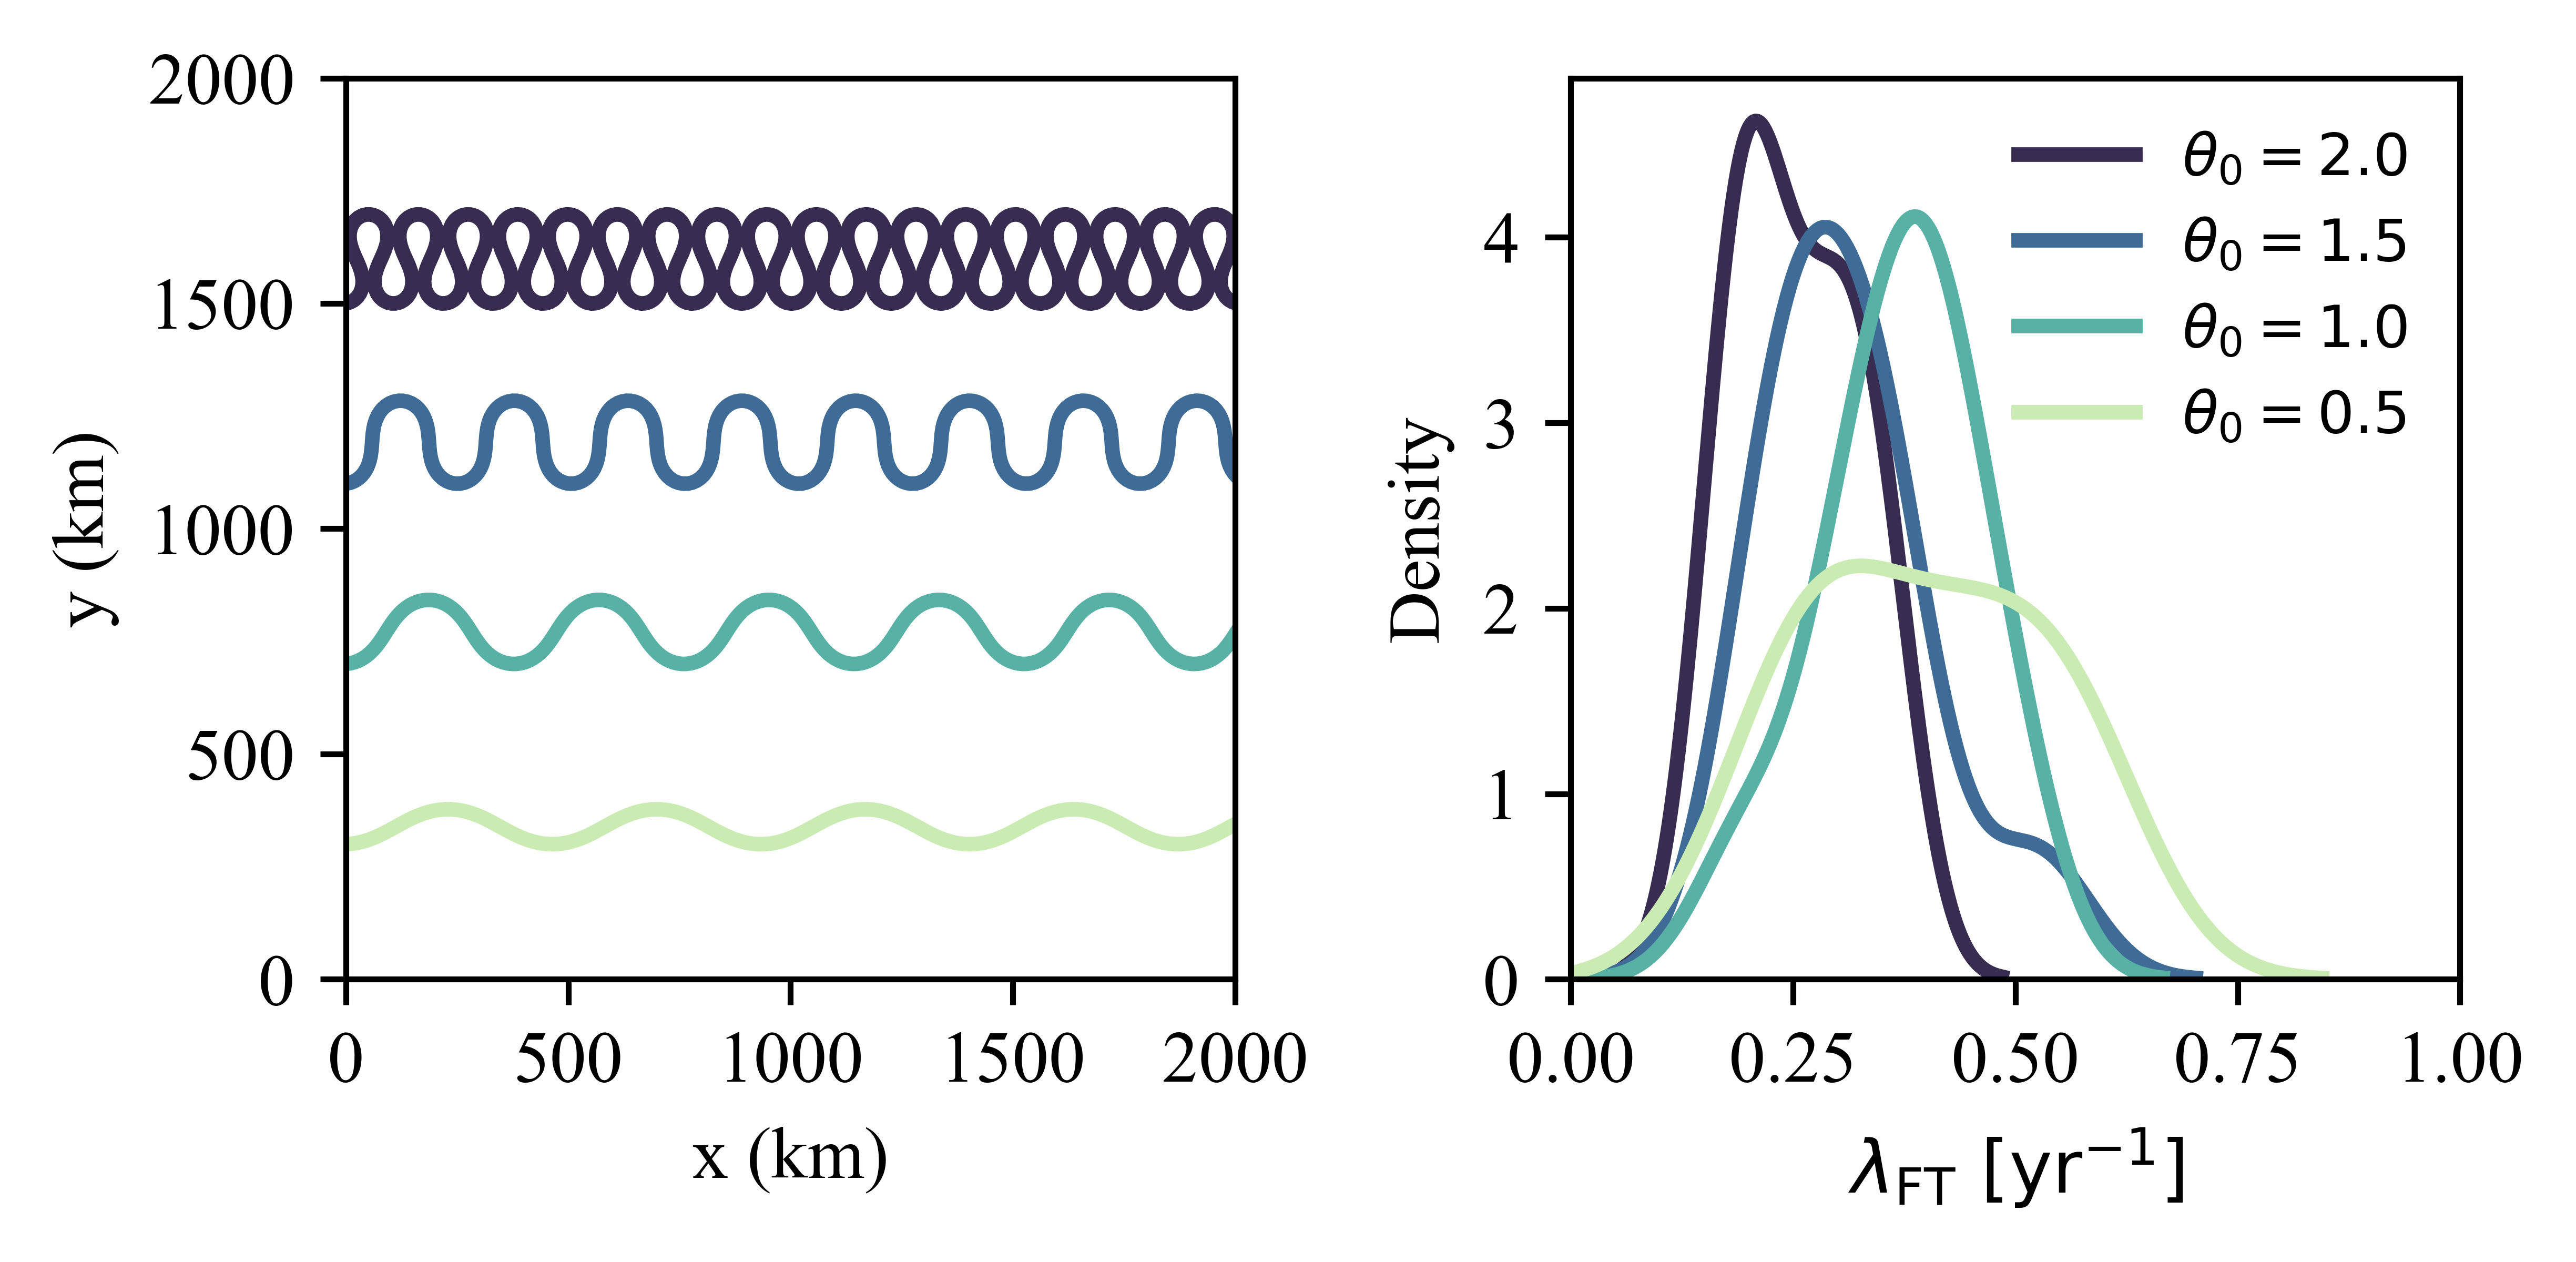

In [135]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cmocean

import numpy as np
import matplotlib.pyplot as plt
import cmocean
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext, FixedLocator
from matplotlib.cm import ScalarMappable

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.dpi"] = 1000



# --- Shared colormap and theta values ---
theta_values = [0.5,1,1.5,2]
cmap = cmocean.cm.deep
colors = cmap(np.linspace(0.1, 0.9, len(theta_values)))  # 4 spaced colors

# --- Right-panel data (KDE) ---
vals = {
    0.5: [0.2012547514396213, 0.4355469666365899, 0.4418331220590611, 0.554701109073589,
          0.5252341046980533, 0.30007916347890135, 0.27194763880467815, 0.2763237778734117,
          0.37316187385463667, 0.5914631092263344],
    1.0: [0.1944202696448967, 0.4643840276143645, 0.33186049977665394, 0.3218499732172743,
          0.3977197570160754, 0.40885813589367825, 0.4984096263673129, 0.28935321536724457,
          0.38874984568543636, 0.3982750825585749],
    1.5: [0.20262738953730222, 0.24601775690267652, 0.2756296548726687, 0.26873160614462055,
          0.5247292126128398, 0.3254209452606462, 0.32756323618559, 0.3763095062331945,
          0.36136738690545356, 0.22342997456897418],
    2.0: [0.17276798858866846, 0.2702287411337351, 0.35563106093262653, 0.31013754182743014,
          0.20991675576313665, 0.34244276660024503, 0.28894749063942154, 0.17273537935078762,
          0.21867274543385043, 0.20392260182270314]
}

# --- Left-panel configuration (channel geometries) ---
lamb = 500.0            # Wavelength (m)
total_length = 10000.0  # Length along the centerline (m)
n_nodes = 1000          # Resolution
base_angle = 0.0
s = np.linspace(0.0, total_length, n_nodes)

# Vertical offsets (so channels don't touch each other)
y_offsets = np.arange(len(theta_values)) * 400.0 + 300

# --- Create subplots ---
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(5,2.5))

# ===== LEFT: Channel geometries =====
for theta0, color, y0 in zip(theta_values, colors, y_offsets):
    theta = theta0 * np.sin(2.0 * np.pi * s / lamb) + base_angle

    x = np.zeros_like(s)
    y = np.zeros_like(s)

    x[0] = 0.0
    y[0] = y0

    for i in range(1, n_nodes):
        ds = s[i] - s[i-1]
        x[i] = x[i-1] + ds * np.cos(theta[i])
        y[i] = y[i-1] + ds * np.sin(theta[i])

    ax_left.plot(x, y, linewidth=2, color=color, label=rf"$\theta_0 = {theta0}$")

ax_left.set_xlabel("x (km)")
ax_left.set_ylabel("y (km)")
ax_left.set_xlim([0, 2000])
ax_left.set_ylim([0, 2000])


for (theta, data), color in reversed(list(zip(vals.items(), colors))):
    sns.kdeplot(
        data,
        color=color,
        linewidth=2,
        label=rf"$\theta_0 = {theta}$",
        fill=False,
        ax=ax_right
    )
    
ax_right.set_ylabel("Density")

ax_right.set_xlabel(r"$\lambda_{\mathrm{FT}}\ \mathrm{[yr^{-1}]}$")

ax_right.set_xlim([0,1])

ax_right.legend(frameon=False, fontsize=8)

plt.tight_layout()

fig.savefig("/Users/braydennoh/Downloads/kineshita.svg", format="svg", bbox_inches="tight")

plt.show()